# Projeto de iniciação tecnlógica 
 >Gêmeos digitais para análise de cibersegurança em sistemas elétricos

#### Para iniciar a abordagem do nosso projeto iremos elencar nossos objetivos abaixo:

>OBJETIVOS GERAIS
 - Implementar a troca de mensagens entre uma rede física e sua versão simulada para que esta última passe a ser o gêmeo digital da primeira, e com isso ser possa analisar a  cibersegurança no elemento digital, sem interferir na rede física.

>OBJETIVOS ESPECÍFICOS
 - Definir forma de interligação de uma rede física com seu modelo;
 - Representar os comportamentos da rede física no modelo digital;
 - Realizar avaliações de segurança cibernética automatizadas no modelo da rede segundo uma matriz de ataques;
 - Produzir, de forma automatizada relatórios de status da cibersegurança da rede;

### Inicio da pesquisa

* Revisão bibliográfica
   - Norma IEC61850 (Ambiente)
     > tutoriais, artigos e guias;
     > Protocolos:
       - o que são mensagens goose ? 
       - O que são mensagens mms ?
       - O que são mensagens simple values ?
       - Arquivos SCL: o que são? como funciona?
     > Palavras-chaves:
       - IEC61850 Tutorial
       - Goose and MMS protocol
       - SDC file structure
   - Norma IEC62443 (Segurança) 
     > zonas, conduítes, security levels  
       - o que são cada um deles?
       

#### Seguindo as linhas de pesquisa 

 Norma IEC61850
  > Camadas:
   - Station level( Interface )
   - Bay level( Ied's )
   - Process level( Aparelhagem e instrumentação: Trafos, dijuntores e etc )

     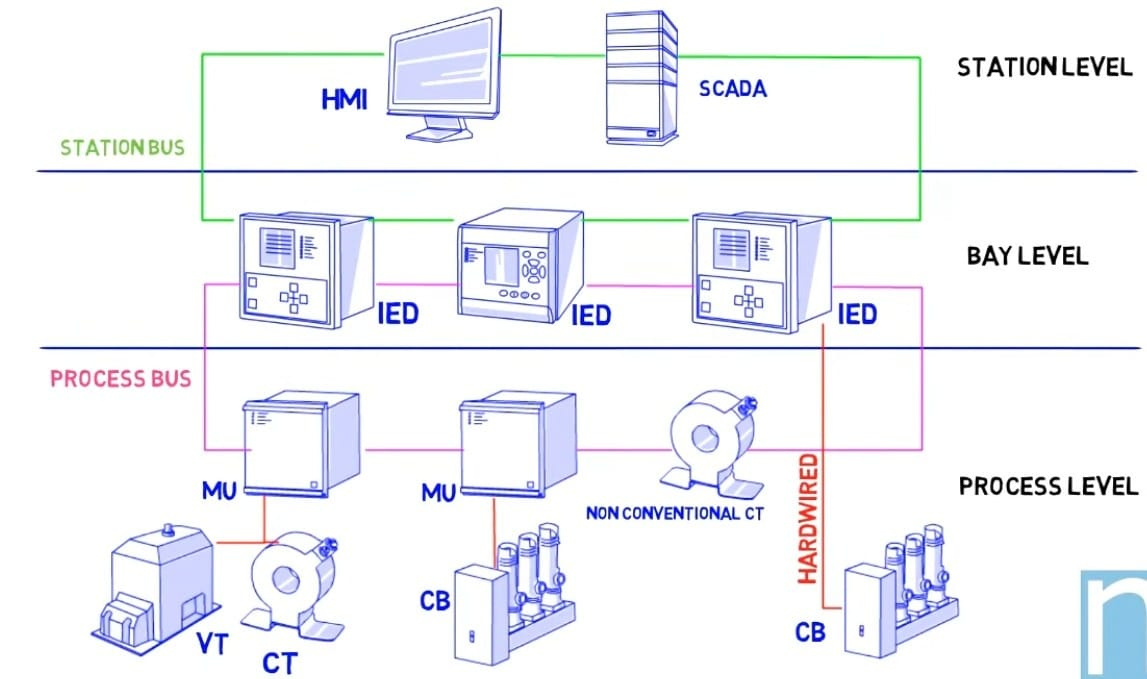
   
  > Camadas de internet:
   - MMS: Transfere dados(Acessa páginas web)
   - TCP: Verifica se as informações foram enviadas corretamente
   - IP: Permite a passagem de dados por redes locais diferentes 
   - LAN: Transmite a informação localmente por cada nó
  > Comucicação entre camadas:
   - Station level ->   MMS   -> Bay level
   - Bay level( Ied ) -> GOOSE ->  Bay level( Ied )
   - Process level -> SIMPLE VALUES -> Bay level 
  > Beneficios da Norma:
   - Usar o padrão ethernet em todo sistema elétrico
   - Comando, controle e supervisão na própria rede
   - Análise em tempo real 
   - Diagnósticos avançados
   - Medição de grandezas em tempo real

### O fluxo do projeto segue da seguinte maneira:
 >Arquivo SCD (planta baixa da substação)
 ->
 >Script de extração dos dados de rede
 -> 
 >Script de criação de topologia (no software GNS3)
 -> 
 >Gêmeo digital criado 
 -> 
 >Fase de testes

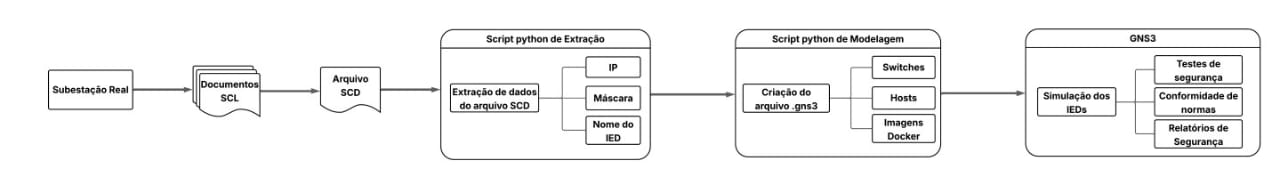

 >Arquivo SCD: Vem direto da substação
   - É como se fosse a planta-baixa da substação
   - Em formato XML, descreve todos os detalhes dos IED's, suas funções e como se conectam a rede e etc.
   - Contém as configurações de comunicação.

### Script de extração em python
  
  Esse scprit irá extrair a partir do arquivo.SCD, baseado em XML, todos os dados necessários dos componentes para modelarmos a topologia do gêmeo digital.

  >exemplo de extração:
  - Número de PCs/IED analisados e retornados: 5
  - Subnetwork: My_network
  - IED Name: XFMR03
  - Access Point Name: E
  - IP Address: 192.168.1.90
  - Subnet Mask: 255.255.255.0
  - Gateway: None

In [ ]:
import xml.etree.ElementTree as ET

def parse_scl(file_path):  # função de extrair informações do arquivo SCL
    # Parse the XML file
    tree = ET.parse(file_path) # carregando o arquivo SCD_model.scd
    root = tree.getroot()   # obtendo a raiz do arquivo XML

    ns = {'scl': 'http://www.iec.ch/61850/2003/SCL'} # cria tags para navegar no XML
    
    ieds = [] # lista para armazenar as informações dos IEDs
    
    for subnetwork in root.findall('scl:Communication/scl:SubNetwork', ns): # navegando até a tag SubNetwork
        subnetwork_name = subnetwork.get('name') # obtendo o nome da subrede
        
        for connected_ap in subnetwork.findall('scl:ConnectedAP', ns): # navegando até a tag ConnectedAP
            ied_name = connefitcted_ap.get('iedName') # obtendo o nome do IED
            ap_name = connected_ap.get('apName') # obtendo o nome do ponto de acesso
            address = connected_ap.find('scl:Address', ns) # navegando até a tag Address
            
            if address is not None: # verificando se a tag Address existe
                ip = address.find('scl:P[@type="IP"]', ns) # obtendo o endereço IP
                subnet = address.find('scl:P[@type="IP-SUBNET"]', ns) # obtendo a máscara de sub-rede
                gateway = address.find('scl:P[@type="IP-GATEWAY"]', ns) # obtendo o gateway
                
                ieds.append({ # armazenando as informações na lista
                    'subnetwork': subnetwork_name, # nome da subrede
                    'ied_name': ied_name,
                    'ap_name': ap_name, # nome do ponto de acesso
                    'ip': ip.text if ip is not None else None,
                    'subnet': subnet.text if subnet is not None else None,
                    'gateway': gateway.text if gateway is not None else None
                })
    
    return ieds # retornando a lista de IEDs com suas informações

if __name__ == "__main__": 
    file_path = '/home/arthur-dev/Desktop/estudos-gêmeosdigitais/Analisador/IEC station 1.scd'
    ied_info = parse_scl(file_path) # chamando a função para extrair as informações do arquivo SCL

    print(f"Número de PCs/IED analisados e retornados:", len(ied_info)) # imprimindo o número de IEDs encontrados

    for ied in ied_info: # imprimindo as informações de cada IED
        print(f"Subnetwork: {ied['subnetwork']}")
        print(f"IED Name: {ied['ied_name']}")
        print(f"Access Point Name: {ied['ap_name']}")
        print(f"IP Address: {ied['ip']}")
        print(f"Subnet Mask: {ied['subnet']}")
        print(f"Gateway: {ied['gateway']}")
        print("-" * 40)

Número de PCs/IED analisados e retornados: 5
Subnetwork: My_network
IED Name: XFMR03
Access Point Name: E
IP Address: 192.168.1.90
Subnet Mask: 255.255.255.0
Gateway: None
----------------------------------------
Subnetwork: My_network
IED Name: XFMR01
Access Point Name: E
IP Address: 192.168.1.70
Subnet Mask: 255.255.255.0
Gateway: None
----------------------------------------
Subnetwork: My_network
IED Name: XFMR02
Access Point Name: E
IP Address: 192.168.1.80
Subnet Mask: 255.255.255.0
Gateway: None
----------------------------------------
Subnetwork: My_network
IED Name: SPARE
Access Point Name: E
IP Address: 192.168.1.100
Subnet Mask: 255.255.255.0
Gateway: None
----------------------------------------
Subnetwork: My_network
IED Name: INCOMER
Access Point Name: E
IP Address: 192.168.1.110
Subnet Mask: 255.255.255.0
Gateway: None
----------------------------------------


### Script python gerador de topologia

Na posse das informações extraidas do arquivo.SCD através do script de extração acima, podemos utiliza-los para gerar a topologia do gêmeo digital no software GNS3.


In [ ]:
import json
import uuid
import os
import math
import subprocess
import sys

# Caminho do arquivo .gns3
gns3_file_path = "/home/arthur-dev/GNS3/projects/cenarios_teste/cenario_teste3.gns3"

# Ler o arquivo .gns3
with open(gns3_file_path, "r") as file:
    gns3_data = json.load(file)

#Definir sempre 4 switches fixos
NUM_SWITCHES = 4
pc_port = 5010  # Porta inicial para PCs

# Definir posições fixas para os switches
switch_positions = [
    (40, -163),     # Switch1
    (323, -163),    # Switch2
    (41, 65),       # Switch3
    (325, 65)       # Switch4
]

# Executar o segundo script e capturar a saída
process = subprocess.Popen(['python3', 'extração_comentado.py'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
output, error = process.communicate()

# Verificar se o script externo executou com sucesso
if process.returncode != 0:
    print(f"Erro ao executar 'extração_comentado.py':\n{error.decode().strip()}")
    exit(1)

# Parsear a saída para capturar as informações de rede
network_info = [] # Lista de dicionários
for line in output.decode().splitlines():
    if "IP Address" in line:
        ip = line.split(": ")[1]
    if "Subnet Mask" in line:
        subnet = line.split(": ")[1]
    if "Gateway" in line:
        gateway = line.split(": ")[1]
        network_info.append({
            "ip": ip,
            "subnet": subnet,
            "gateway": gateway
        })

num_pcs = len(network_info)
print(f"Tamanho da lista de redes capturadas: {num_pcs}")

# Validar se há informações de rede suficientes para todos os PCs
if len(network_info) < num_pcs:
    print(f"Erro: O script externo retornou informações de rede insuficientes. "
        f"Esperado: {num_pcs}, Recebido: {len(network_info)}.")
    exit(1)

# IDs e contadores
pc_port = 5010  # Porta inicial para PCs

# Função para criar um contêiner Docker
def create_oraculo_container():
    node_id = str(uuid.uuid4())  # UUID completo com hífens para o node_id
    container_id = node_id.replace("-", "")  # Apenas hexadecimal (sem hífens) para container_id
    docker_container = {
        "compute_id": "local",
        "console": 5005,
        "console_auto_start": False,
        "console_type": "telnet",
        "custom_adapters": [],
        "first_port_name": None,
        "height": 59,
        "label": {
            "rotation": 0,
            "style": "font-family: TypeWriter;font-size: 10.0;font-weight: bold;fill: #000000;fill-opacity: 1.0;",
            "text": "oraculo-1",
            "x": -5,
            "y": -25
        },
        "locked": False,
        "name": "oraculo-1",
        "node_id": node_id,  # UUID completo para o node_id
        "node_type": "docker",
        "port_name_format": "Ethernet{0}",
        "port_segment_size": 0,
        "properties": {
            "adapters": 1,
            "aux": 5006,
            "console_http_path": "/",
            "console_http_port": 80,
            "console_resolution": "1024x768",
            "container_id": container_id,  # Hexadecimal para o container_id
            "image": "oraculo:latest",
            "start_command": None,
            "usage": ""
        },
        "symbol": ":/symbols/docker_guest.svg",
        "template_id": "7f6da3e9-0dba-423b-82e4-18014b5f2922",
        "width": 65,
        "x": -206,
        "y": -106,
        "z": 1
    }
    return docker_container, node_id

# Função para criar um PC
def create_pc_container(pc_number, switch_x, switch_y):
    node_id = str(uuid.uuid4())  # UUID para node_id
    container_id = node_id.replace("-", "")  # Hexadecimal para container_id
    pc_network = network_info[pc_number - 1]  # Pegar as infos de rede para este PC
    pc_container = {
        "compute_id": "local",
        "console": pc_port + pc_number,  # Porta console baseada no número do PC
        "console_auto_start": False,
        "console_type": "telnet",
        "custom_adapters": [],
        "first_port_name": None,
        "height": 59,
        "label": {
            "rotation": 0,
            "style": "font-family: TypeWriter;font-size: 10.0;font-weight: bold;fill: #000000;fill-opacity: 1.0;",
            "text": f"ubuntu-ied-{pc_number}",
            "x": -38,
            "y": -25
        },
        "locked": False,
        "name": f"ubuntu-ied-{pc_number}",
        "node_id": node_id,
        "node_type": "docker",
        "port_name_format": "Ethernet{0}",
        "port_segment_size": 0,
        "properties": {
            "adapters": 1,
            "aux": pc_port + pc_number + 1,  # Porta auxiliar baseada no número do PC
            "console_http_path": "/",
            "console_http_port": 80,
            "console_resolution": "1024x768",
            "container_id": container_id,  # Identificador hexadecimal para o contêiner
            "environment": None,
            "extra_hosts": None,
            "extra_volumes": [],
            "image": "ubuntu-ied:latest",  # Imagem Docker   >>>>>>>>>!!!! MUDAR AQUI TODA VEZ QUE ATUALIZAR A IMAGEM DOCKER !!!!!<<<<<<<<<<<<<<<<<
            "start_command": None,
            "usage": ""
        },
        "symbol": ":/symbols/docker_guest.svg",
        "template_id": "5f343939-8f35-4f8c-93c4-7676e6419a77",  # ID do template fornecido
        "width": 65,
        "x": switch_x - 100 + pc_number * 50,  # Posicionamento horizontal ajustado
        "y": switch_y - 200,  # Posicionamento vertical ajustado
        "z": 1
    }
    # Criar diretório para o novo PC
    new_pc_dir = f"/home/arthur-dev/GNS3/projects/cenarios_teste/project-files/docker/{node_id}/etc/network"
    os.makedirs(new_pc_dir, exist_ok=True)

    # Criar arquivo de configuração do novo PC
    interface = f"""#
# This is a sample network config, please uncomment lines to configure the network
#

# Uncomment this line to load custom interface files
# source /etc/network/interfaces.d/*

# Static config for eth0
auto eth0
iface eth0 inet static
	address {pc_network['ip']}
	netmask {pc_network['subnet']}
	gateway {pc_network['gateway']}
	up echo nameserver 192.168.1.1 > /etc/resolv.conf

# DHCP config for eth0
#auto eth0
#iface eth0 inet dhcp
#	hostname ubuntu-ied-{pc_number}
"""
    interface_path = os.path.join(new_pc_dir, "interfaces")
    with open(interface_path, "w") as file:
        file.write(interface)
    print(f"Configuração de rede escrita para PC {pc_container['name']} com IP {pc_network['ip']}")

    return pc_container, node_id



# Função para criar um switch
def create_switch(switch_number, x, y):
    node_id = str(uuid.uuid4())
    container_id = node_id.replace("-", "")  # Simplesmente usando parte do UUID como container_id

    switch_config = {
        "compute_id": "local",
        "console": 5000 + switch_number,  # Porta console única para cada switch
        "console_auto_start": False,
        "console_type": "telnet",
        "custom_adapters": [],
        "first_port_name": None,
        "height": 48,
        "label": {
            "rotation": 0,
            "style": "font-family: TypeWriter;font-size: 10.0;font-weight: bold;fill: #000000;fill-opacity: 1.0;",
            "text": f"OpenvSwitch-{switch_number}",
            "x": -33,
            "y": -25
        },
        "locked": False,
        "name": f"OpenvSwitch-{switch_number}",
        "node_id": node_id,
        "node_type": "docker",
        "port_name_format": "Ethernet{0}",
        "port_segment_size": 0,
        "properties": {
            "adapters": 16,  # Número de interfaces (pode ser ajustado conforme necessidade)
            "aux": 5000 + switch_number + 1,  # Porta auxiliar única
            "console_http_path": "/",
            "console_http_port": 80,
            "console_resolution": "1024x768",
            "container_id": container_id[:64],  # Limitando a 64 caracteres se necessário
            "environment": None,
            "extra_hosts": None,
            "extra_volumes": [],
            "image": "gns3/openvswitch:latest",
            "start_command": None,
            "usage": "By default all interfaces are connected to the br0"
        },
        "symbol": ":/symbols/classic/multilayer_switch.svg",
        "template_id": "34c4edc6-de68-4ea5-9b26-b597c4846874",  # Template ID para Open vSwitch
        "width": 51,
        "x": x,
        "y": y,
        "z": 1
    }
    
    return switch_config, node_id


# Função para criar um link entre dois nodes
def create_link(node1_id, node1_port, node2_id, node2_port):
    link_id = str(uuid.uuid4())
    return {
        "filters": {},
        "link_id": link_id,
        "link_style":{},
        "nodes": [
            {
                "adapter_number": node1_port,
                "label": {
                    "rotation": 0,
                    "style": "font-family: TypeWriter;font-size: 10.0;font-weight: bold;fill: #000000;fill-opacity: 1.0;",
                    "text": f"eth{node1_port}",
                    "x": 25,
                    "y": 15
                },
                "node_id": node1_id,
                "port_number": 0
            },
            {
                "adapter_number": node2_port,
                "label": {
                    "rotation": 0,
                    "style": "font-family: TypeWriter;font-size: 10.0;font-weight: bold;fill: #000000;fill-opacity: 1.0;",
                    "text": f"eth{node2_port}",
                    "x": 25,
                    "y": 15
                },
                "node_id": node2_id,
                "port_number": 0
            }
        ],
        "suspend": False
    }

# Adicionar switches à topologia
switch_ids = []
for i in range(NUM_SWITCHES):
    switch, switch_id = create_switch(i + 1, *switch_positions[i])
    gns3_data["topology"]["nodes"].append(switch)
    switch_ids.append(switch_id)


# Criar links entre os switches conforme a topologia desejada
gns3_data["topology"]["links"].extend([
    create_link(switch_ids[0], 0, switch_ids[1], 0),    # Switch1 <-> Switch2
    create_link(switch_ids[1], 1, switch_ids[3], 0),    # Switch2 <-> Switch4
    create_link(switch_ids[3], 1, switch_ids[2], 0),    # Switch4 <-> Switch3
    create_link(switch_ids[2], 1, switch_ids[0], 1),    # Switch3 <-> Switch1
    create_link(switch_ids[0], 2, switch_ids[3], 2),    # Switch1 <-> Switch4
    create_link(switch_ids[2], 2, switch_ids[1], 2)     # Switch3 <-> Switch2
])

# Distribuir PCs entre os 4 switches
pcs_per_switch = math.ceil(num_pcs / NUM_SWITCHES)
pc_counter = 0
for switch_id, (switch_x, switch_y) in zip(switch_ids, switch_positions):
    for i in range(pcs_per_switch):
        if pc_counter >= num_pcs:
            break
        pc, pc_id = create_pc_container(pc_counter + 1, switch_x, switch_y)
        gns3_data["topology"]["nodes"].append(pc)
        link = create_link(pc_id, 0, switch_id, i+3)
        gns3_data["topology"]["links"].append(link)
        pc_counter += 1

# Adicionar contêiner Docker e linká-lo ao Switch1 na porta e5
docker_container, docker_id = create_oraculo_container()
gns3_data["topology"]["nodes"].append(docker_container)
link = create_link(docker_id, 0, switch_ids[0], 5)  # Conecta Docker ao Switch1 na porta Ethernet5
gns3_data["topology"]["links"].append(link)

# Salvar mudanças no arquivo .gns3
with open(gns3_file_path, "w") as file:
    json.dump(gns3_data, file, indent=4)

print(f"Topologia atualizada com {NUM_SWITCHES} switches e {num_pcs} PCs.")

>Exemplo de topologia gerada:
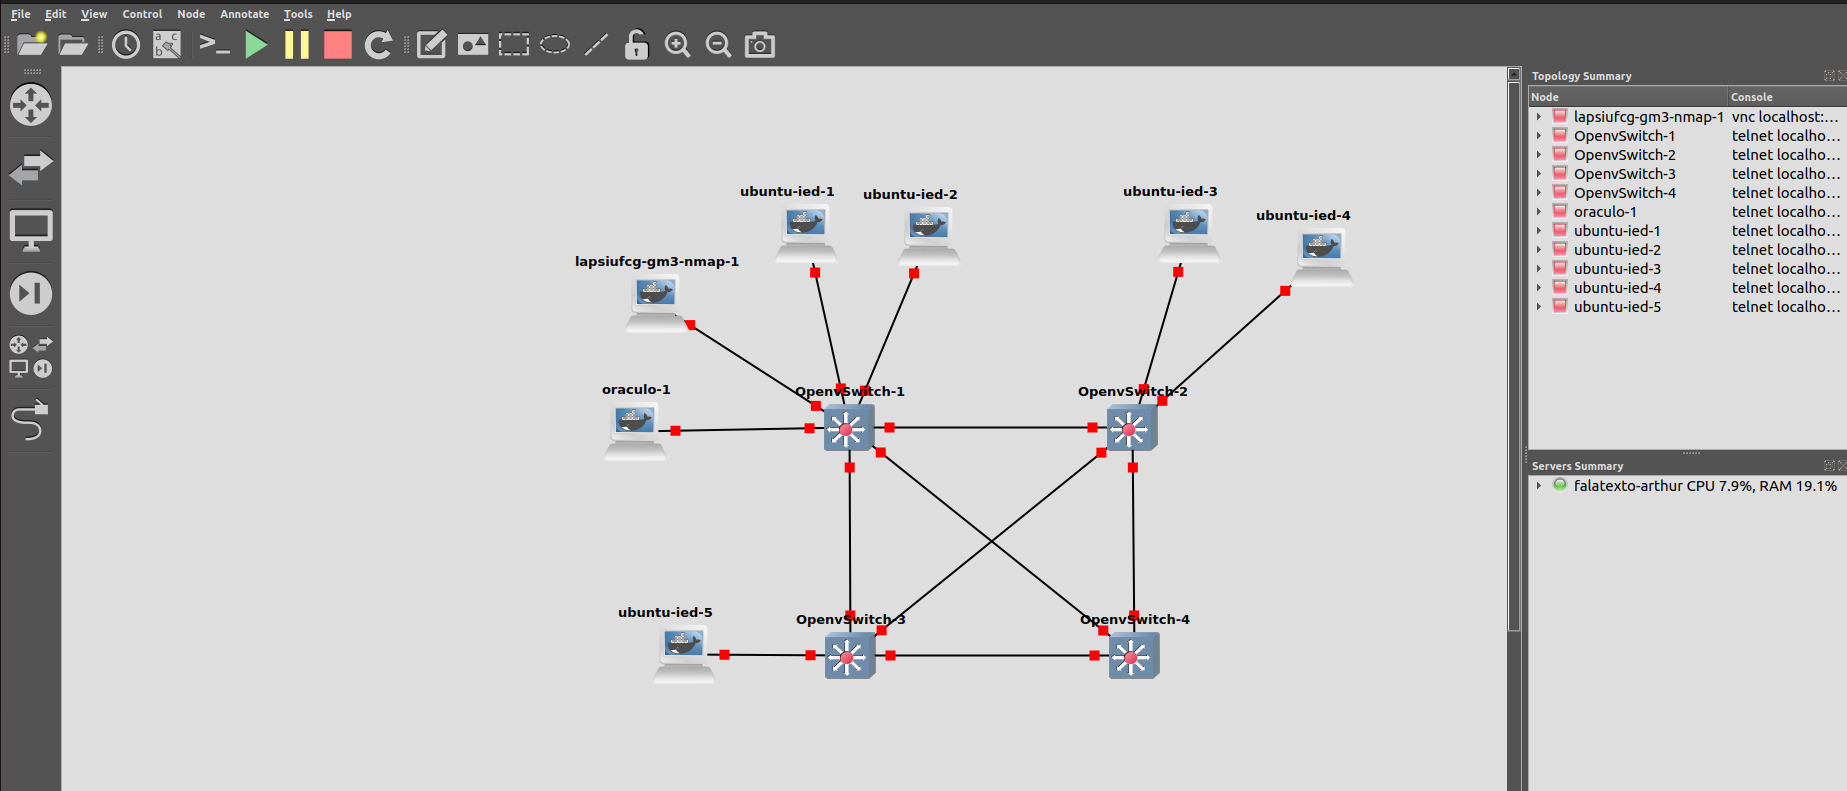

### Fase de testes

> Software Grassmarlin
 - Usado para mapear a topologia de forma passiva.Assim, não interferindo na rede de comunicação. 
 - Com foco principal em áreas críticas como: usinas de energia, rede elétrica , linhas de produção e etc.
 - Sistemas como: ISC e SCADA
 - Pode ser usado para verificar a conformidade e validação do gêmeo digital.
  
    > Problemas enfrentados:
    - Configuração dos switches mais complexos 
    - 

#### Teste do Grassmarlin no cenário simples

  > Grassmarlin cenário_teste.1
   - Após algumas semanas de teste e não obtendo sucesso na captura do tráfego de rede, segui para uma topologia mais simples, essa descrita abaixo:
   - 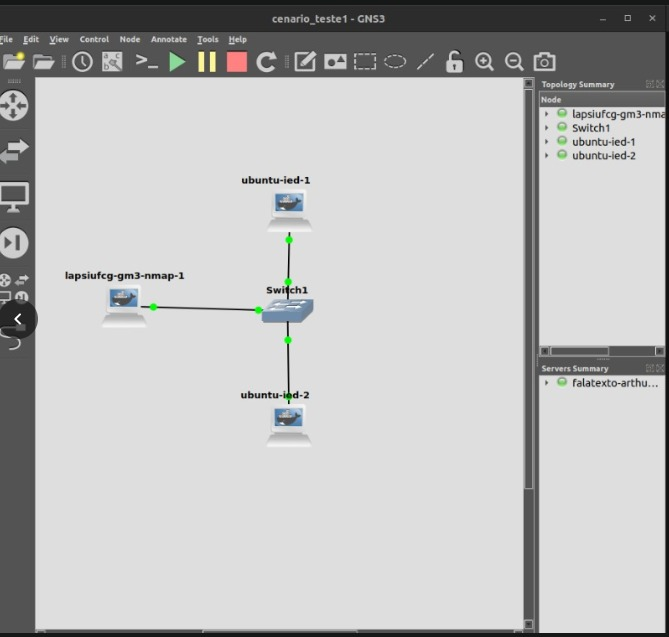
   - Analizando alguns dados de rede, decidi pingar dos host's para o grassmarlin.Após alguns segundos analisando, ele conseguiu capturar os host's da rede.
   - 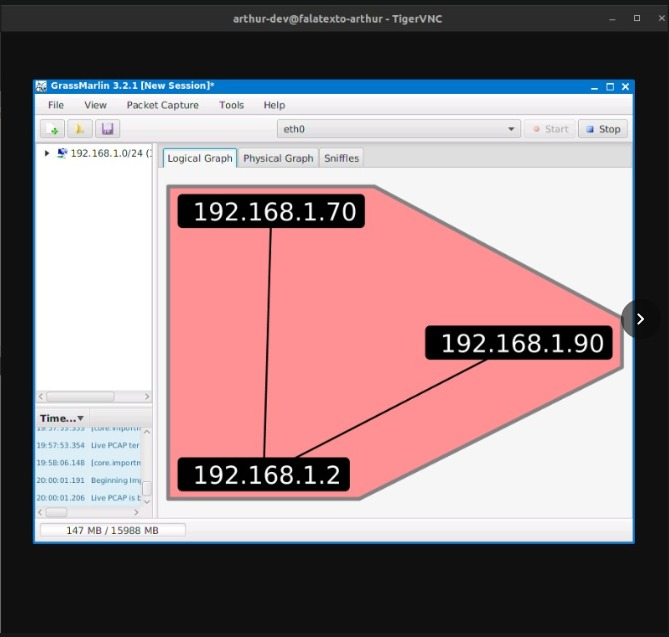

  > Grassmarlin cenário_teste.2
   - Aplicando os mesmos testes no cenário mais complexo, obtivemos os mesmos resultados positivos.Porém, conseguimos identificar o não espelhamento dos hosts ao Grassmarlin.
   - 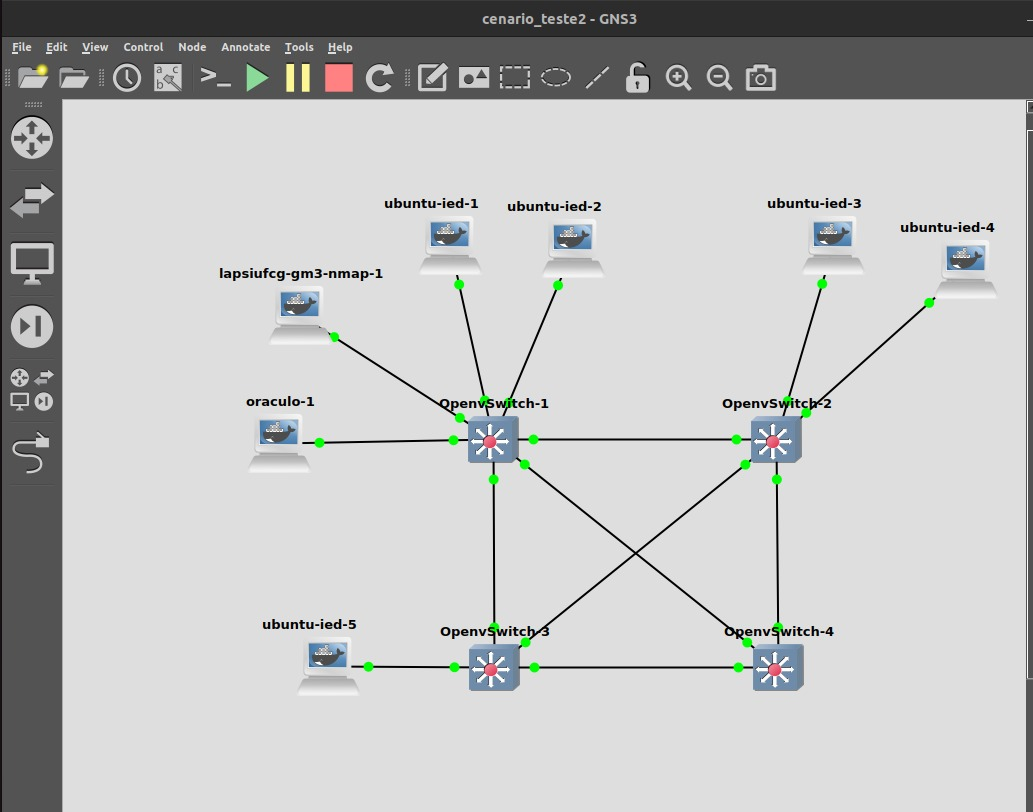  
   - Resultado da captura:
   - 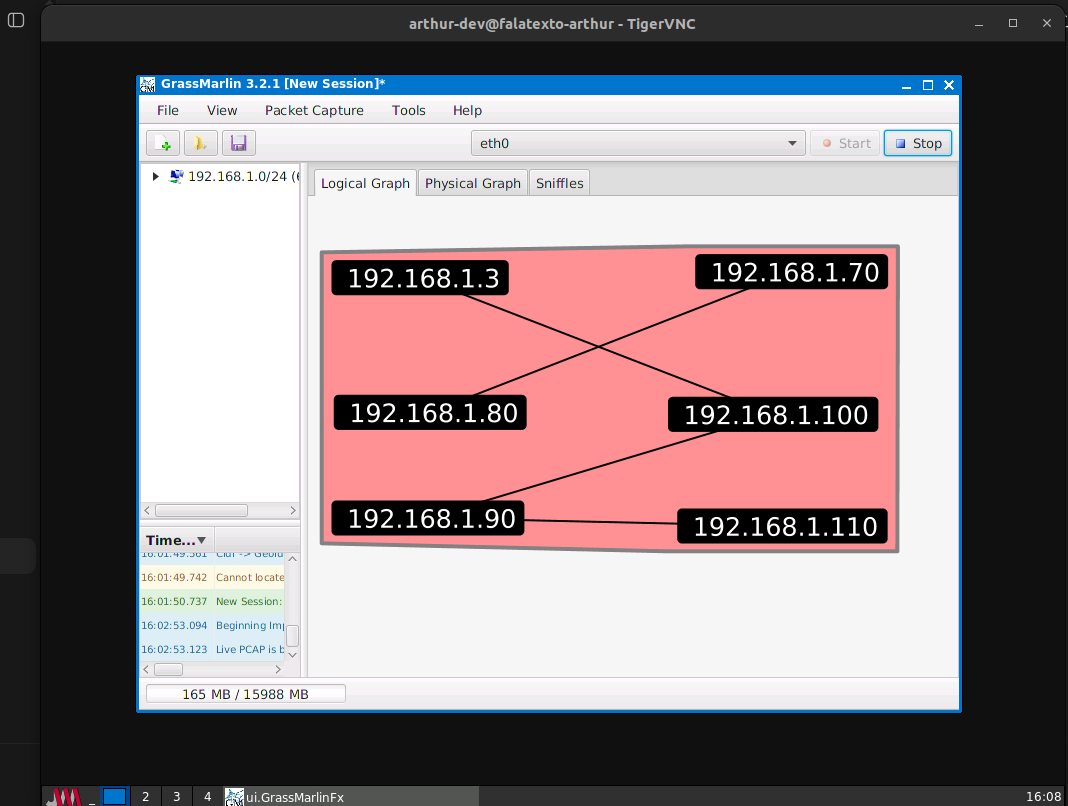

### Voltando para topologia mais complexa.
  - fazer os mesmos testes de ping reverso
  - verificar os switches opensv e suas configurações  


  > Grassmarlin resolvido
  - Funcional de forma passiva(sensor)
  - Conseguiu mapear toda topologia

### Aplicação da IEC62443

- Segmentação em zonas e conduítes
- Criar VLAN para caracterizar as zonas


### Segmentação e caracterização de zonas 

> IEDs
- Zona Process Bus 1
- VLAN 10
- Protocolos: GOOSE e Simple Values 

   - ubuntu-ied-1 
   - ubuntu-ied-2 
   - ubuntu-ied-3  
   - ubuntu-ied-4
   - ubuntu-ied-5

> Oráculo(SCADA)
- Zona Station BUS
- VLAN 20
- Protocolo: MMS

   - Oraculo-1

> Grassmarlin (Analizador)
- Zona Admin
- VLAN 30
- Protocolo: SSH

   - lapsiufcg-gm3-nmap-1

  


### Segmentação de conduítes

> Fluxos permitidos

| Origem      | Destino     | Permitido   |
| ----------- | ----------- | ----------- |
| Process Bus | Process Bus | GOOSE, SV   |
| Station Bus | Process Bus | MMS         |
| Admin | Station Bus | manutenção  |

- Não geram alerta

> Fluxos proibidos


| Origem      | Destino     | Proibido   |
| ----------- | ----------- | ----------- |
|   Admin | Process Bus | MMS  |
| Station Bus | Process Bus | GOOSE         |
| Station Bus | Process Bus | SV         |

- Geram alerta
 


